In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("coffee_sales_cleaned.csv")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_bucket
0,1,2025,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Morning
1,2,2025,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning
2,3,2025,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Morning
3,4,2025,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Morning
4,5,2025,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning


### EDA

In [69]:
df.shape

(149116, 14)

In [70]:
df.columns

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'revenue', 'hour',
       'time_bucket'],
      dtype='object')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
 11  revenue           149116 non-null  float64
 12  hour              149116 non-null  int64  
 13  time_bucket       149116 non-null  object 
dtypes: float64(2), int64(6), object(6)
memory usage: 15.9+ MB


In [72]:
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
revenue             0
hour                0
time_bucket         0
dtype: int64

In [73]:
df.duplicated(subset="transaction_id").sum()

0

In [74]:
# if duplicate exist
# df = df.drop_duplicates(subset="transaction_id")

In [75]:
#quantity and price are positive
(df["transaction_qty"] <= 0).sum()

0

In [76]:
(df["unit_price"] <= 0).sum()

0

In [79]:
# convert the time column into proper datetime format
df["transaction_time"] = pd.to_datetime(df["transaction_time"])
df["hour"] = df["transaction_time"].dt.hour

In [80]:
df["transaction_time"].head()

0   1900-01-01 07:06:11
1   1900-01-01 07:08:56
2   1900-01-01 07:14:04
3   1900-01-01 07:20:24
4   1900-01-01 07:22:41
Name: transaction_time, dtype: datetime64[ns]

In [81]:
df.dtypes

transaction_id               int64
year                         int64
transaction_time    datetime64[ns]
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
revenue                    float64
hour                         int32
time_bucket                 object
dtype: object

In [82]:
df.shape

(149116, 14)

### Feature Engineering

In [83]:
# creating revenue column (Revenue per transaction = quantity × price)
df["revenue"] = df["transaction_qty"] * df["unit_price"]
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_bucket
0,1,2025,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Morning
1,2,2025,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning
2,3,2025,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Morning
3,4,2025,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Morning
4,5,2025,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning


In [84]:
# Extracting Hour of Transaction(to identify peak hours)
df["hour"] = df["transaction_time"].dt.hour
df[["transaction_time","hour"]].head()

,transaction_time,hour
0,1900-01-01 07:06:11,7
1,1900-01-01 07:08:56,7
2,1900-01-01 07:14:04,7
3,1900-01-01 07:20:24,7
4,1900-01-01 07:22:41,7


In [85]:
# Extract Day of Week(to identify busiest days)
df["day_of_week"] = df["transaction_time"].dt.day_name()
df["day_of_week"].value_counts()

day_of_week
Monday    149116
Name: count, dtype: int64

In [86]:
df.columns


Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'revenue', 'hour',
       'time_bucket', 'day_of_week'],
      dtype='object')

In [87]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,time_bucket,day_of_week
0,1,2025,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Morning,Monday
1,2,2025,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning,Monday
2,3,2025,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Morning,Monday
3,4,2025,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Morning,Monday
4,5,2025,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Morning,Monday


In [88]:
df = df.drop(columns=["day_of_week"])

In [89]:
df.columns


Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'revenue', 'hour',
       'time_bucket'],
      dtype='object')

In [90]:
def time_bucket(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 21:
        return "Evening"
    else:
        return "Late Night"

df["time_bucket"] = df["hour"].apply(time_bucket)


In [91]:
df[["hour","time_bucket"]].head(10)

,hour,time_bucket
0,7,Morning
1,7,Morning
2,7,Morning
3,7,Morning
4,7,Morning
5,7,Morning
6,7,Morning
7,7,Morning
8,7,Morning
9,7,Morning


In [92]:
df["time_bucket"].unique()

array(['Morning', 'Afternoon', 'Evening'], dtype=object)

### Overall Sales Trend Analysis

In [93]:
# Total Revenue of the Dataset
df["revenue"].sum()

698812.3300000002

In [94]:
df["revenue"].mean()

4.686367190643527

In [95]:
# Total Transactions per Hour(identifies busy hours)
hourly_transactions = df.groupby("hour")["transaction_id"].count()
hourly_transactions

hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: transaction_id, dtype: int64

In [96]:
# Revenue by Hour
hourly_revenue = df.groupby("hour")["revenue"].sum()
hourly_revenue

hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: revenue, dtype: float64

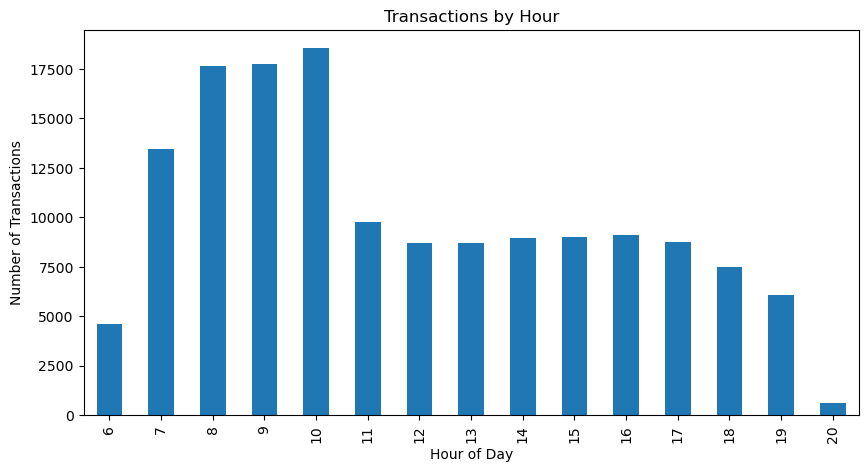

In [97]:
# Transactions by Hour(show customer rush hours)
plt.figure(figsize=(10,5))
hourly_transactions.plot(kind="bar")

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

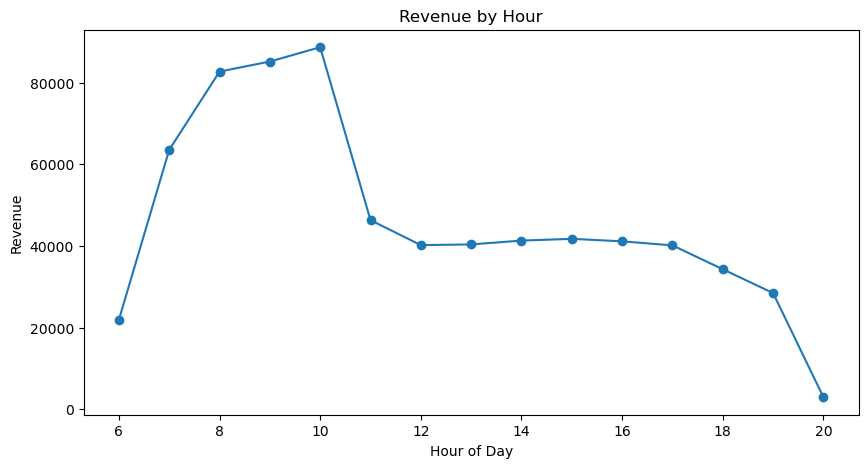

In [98]:
# Revenue by Hour(shows when most money is generated)
plt.figure(figsize=(10,5))
hourly_revenue.plot(kind="line", marker="o")

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.show()

In [99]:
#Time Bucket Performance(analyze Morning vs Afternoon vs Evening)
bucket_sales = df.groupby("time_bucket")["revenue"].sum()
bucket_sales

time_bucket
Afternoon    204720.83
Evening      105802.83
Morning      388288.67
Name: revenue, dtype: float64

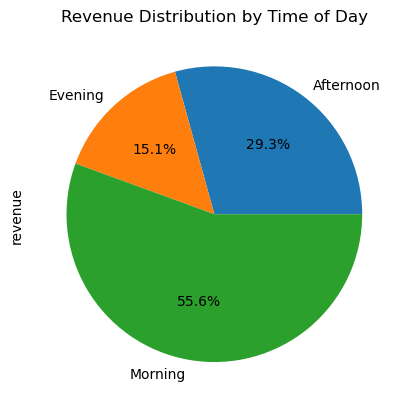

In [100]:
bucket_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Revenue Distribution by Time of Day")

plt.show()


### Store Location Performance Analysis

In [101]:
#which store locations generate the most revenue
store_revenue = df.groupby("store_location")["revenue"].sum()
store_revenue


store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64

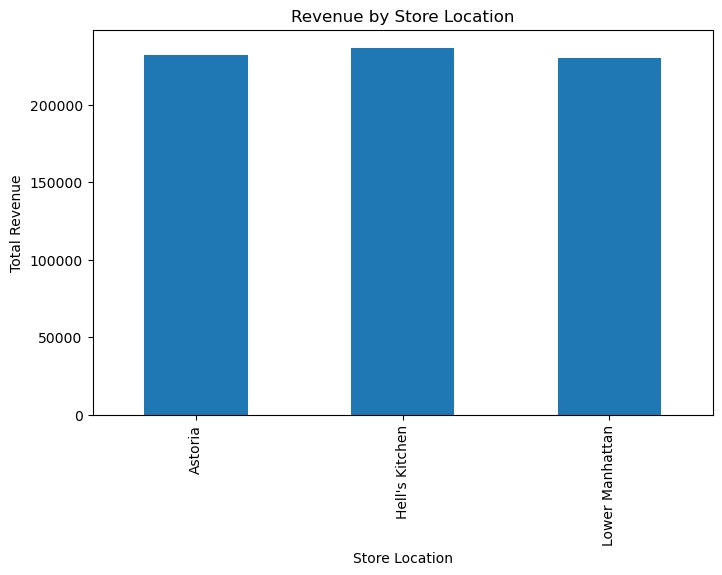

In [102]:
plt.figure(figsize=(8,5))

store_revenue.plot(kind="bar")

plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.show()

In [103]:
# Transaction Count per Store
store_transactions = df.groupby("store_location")["transaction_id"].count()
store_transactions

store_location
Astoria            50599
Hell's Kitchen     50735
Lower Manhattan    47782
Name: transaction_id, dtype: int64

In [104]:
# Revenue by Store
store_revenue = df.groupby("store_location")["revenue"].sum()
store_revenue

store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64

### Hourly Demand Heatmap

In [105]:
# Hourly Store Revenue
pivot_hour_store = df.pivot_table(
    values="revenue",
    index="hour",
    columns="store_location",
    aggfunc="sum"
)

pivot_hour_store


store_location,Astoria,Hell's Kitchen,Lower Manhattan
hour,,,
6,NaN,7531.17,14369.10
7,19028.80,15961.05,28536.62
8,22805.90,31544.44,28349.53
9,23183.57,32874.29,29111.67
10,24426.12,33605.81,30641.46
11,15498.13,17926.54,12894.47
12,15681.20,11343.10,13168.49
13,15947.87,12070.10,12349.48
14,15175.27,12297.50,13831.97


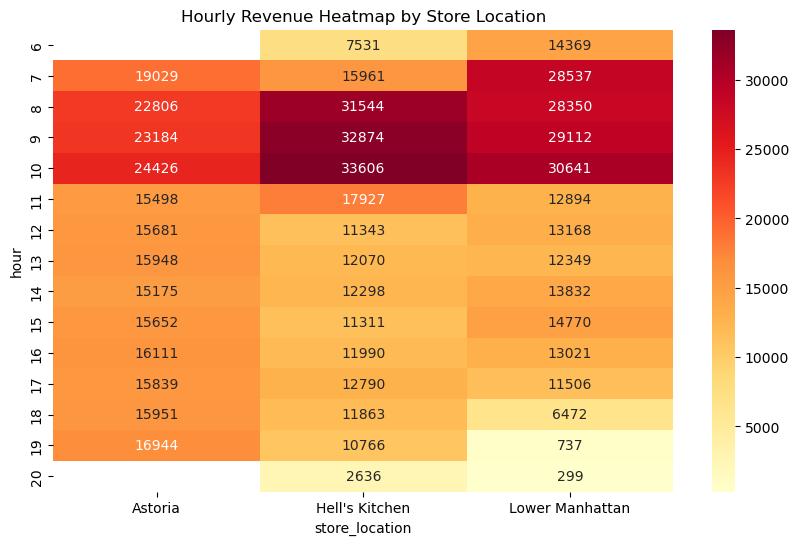

In [106]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_hour_store,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Hourly Revenue Heatmap by Store Location")

plt.show()


### Product Category Sales Analysis

In [107]:
# Revenue by Product Category
category_revenue = df.groupby("product_category")["revenue"].sum()
category_revenue.sort_values(ascending=False)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: revenue, dtype: float64

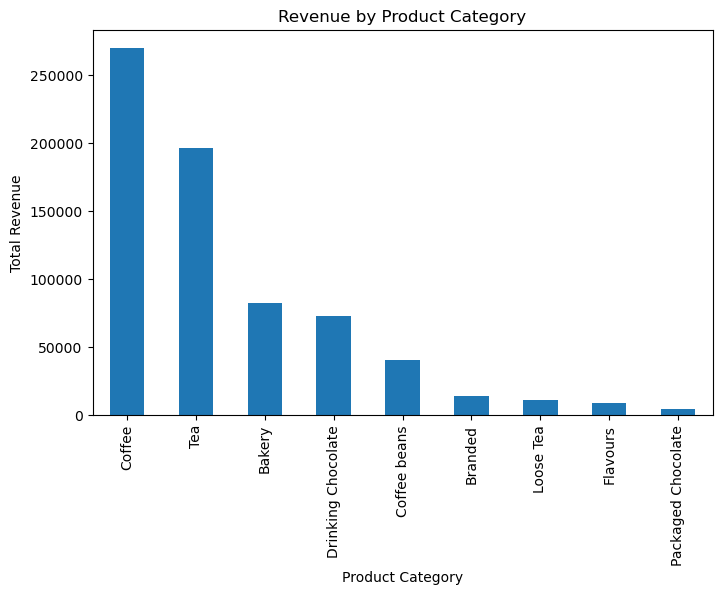

In [108]:
plt.figure(figsize=(8,5))

category_revenue.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()


In [109]:
# Transaction Count by Product Category
category_transactions = df.groupby("product_category")["transaction_id"].count()
category_transactions.sort_values(ascending=False)

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: transaction_id, dtype: int64

### 
Top Selling Products Analysis

In [110]:
# Top 10 Products by Revenue
top_products = df.groupby("product_type")["revenue"].sum()
top_products.sort_values(ascending=False).head(10)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: revenue, dtype: float64

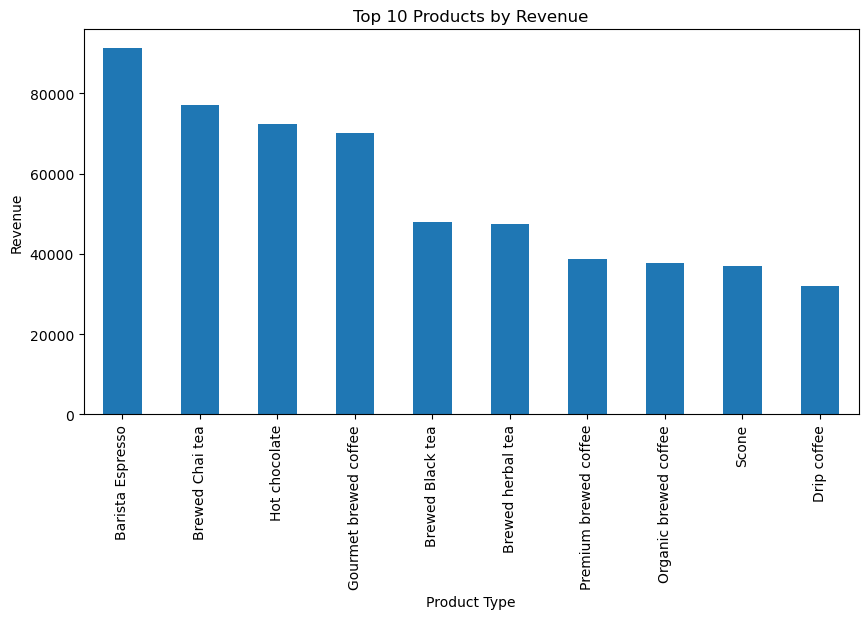

In [111]:
plt.figure(figsize=(10,5))

top_products.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Type")
plt.ylabel("Revenue")

plt.show()


In [112]:
# Top Products by Transaction Count
top_products_transactions = df.groupby("product_type")["transaction_id"].count()
top_products_transactions.sort_values(ascending=False).head(3)

product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Name: transaction_id, dtype: int64

## Conclusion

This analysis examined transaction-level data from Afficionado Coffee Roasters to understand temporal sales patterns, store performance, and product demand.
The findings reveal that morning hours dominate coffee sales, with the peak revenue occurring around 10 AM. This aligns with typical commuter behavior where customers purchase beverages before work.
Among the three store locations, Hell's Kitchen generated the highest revenue, though the difference between locations was relatively small, suggesting consistent brand performance across stores.
Product analysis showed that coffee beverages are the primary revenue drivers, with Brewed Chai Tea, Gourmet Brewed Coffee, and Barista Espresso emerging as the top-selling products.
These insights can help management optimize staffing schedules, improve inventory planning, and implement targeted promotions during slower periods.

In [114]:
# Create revenue
df["revenue"] = df["transaction_qty"] * df["unit_price"]

# Save as CSV
df.to_csv("coffee_sales_cleaned.csv", index=False)

print("CSV created")

CSV created
